# Week 11 Capstone: corruption-aware GP-UCB review

The stored Week 11 arrays and claimed Week 10 returns fail provenance checks. This notebook therefore retains the 223 verified observations, marks Weeks 5, 7, and 10 pending, reviews F1–F8, and generates reproducible Week 11 GP-UCB proposals without treating proposals or copied values as evaluations.

## Errors found and corrected

1. `/content/week_10_dataset.zip` and all Google Drive paths are unavailable.
2. Repository-native Week 11 arrays are corrupted: `64` becomes the maximum in seven unrelated functions, rows are duplicated, outputs are shifted, and F8 coordinates are segmented incorrectly.
3. The claimed Week 10 returns are not credible new evaluations: five outputs exactly copy Week 9 values despite different inputs; three differ only by tiny digit edits. They remain pending.
4. The valid `week_12_query_points.txt` contains proposals, not returned observations, and must not enter model training.
5. The markdown says 'For each function for Week_10' inside Week 11. Week labels are corrected.
6. Drive mounting and writes mutate external state and prevent local reproducibility.
7. `display()` is used without a guaranteed import.
8. EDA generates dozens of fragmented figures and overstates correlation as sensitivity.
9. Targets are manually standardised with `normalize_y=False`; one transparent GP normalisation path is used instead.
10. Function 1 is optimised twice, 100,000 candidates are converted to Python tuples, and the output is mislabeled as Week 12.
11. Evidence gaps were omitted from the summary and copied diagnostics could be mistaken for retained historical models.

In [1]:
from pathlib import Path
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

FUNCTIONS=tuple(range(1,9)); DIMS={1:2,2:2,3:3,4:4,5:4,6:5,7:6,8:8}; KAPPA={i:2. for i in FUNCTIONS}
RQ={1:[[.375440,.950714],[.536429,.835362],[.614168,.334143],[.872626,.321598]],2:[[.375440,.950714],[.978752,.932731],[.000006,.334143],[.197553,.808683]],3:[[.444444,.666666,.333333],[.657452,.998464,.817253],[.670026,.057881,.658241],[.650132,.218327,.110542]],4:[[.555555,.444444,.222222,.111111],[.006280,.281840,.932013,.960202],[.394519,.361122,.256803,.461856],[.715715,.504442,.275065,.552962]],5:[[.224189,.846480,.879484,.878515],[.255841,.841692,.888984,.860260],[.255842,.841692,.888985,.860266],[0.,0.,0.,0.]],6:[[.728186,.154693,.732552,.693997,.564013],[.433654,.486678,.282753,.972905,.323321],[.495070,.097152,.672921,.000007,.351268],[.973181,.022807,.714484,.145453,.974790]],7:[[.045091,.528666,.329265,.105350,.434667,.641164],[.243848,.900100,.696978,.193630,.374149,.826324],[.143585,.302559,.571101,.194533,.395561,.815792],[.045103,.016167,.773003,.156031,.147073,.616114]],8:[[.273673,.260400,.073937,.078562,.862321,.230729,.106880,.352588],[.163160,.184786,.152644,.083802,.999322,.544113,.184124,.123846],[.088894,.525132,.030986,.992538,.870819,.217060,.011239,.447691],[.356502,.157574,.172997,.610561,.106477,.260297,.411421,.904740]]}
RY={1:[-1.560646704467778e-117,1.674933466363685e-36,-1.0755942664604116e-32,-2.4666412561217706e-107],2:[-.03182956281754251,.022666631114895516,.04868370128566149,.038774938576018964],3:[-.04090761844901528,-.08987474979637637,-.18323876643005035,-.08251349582236739],4:[-8.727516493155957,-31.73535839431216,-1.9810750402526334,-9.312811809021998],5:[1088.8535114737463,1035.6341457754475,1035.6647479285914,163.1225],6:[-1.1520351120911565,-.8782405650300305,-1.339542402620705,-2.4375082517089726],7:[1.0510148516295004,.308765180253091,2.149905456773691,1.2087334449610816],8:[9.8157087929671,9.9399041910574,8.9636037557014,9.2540644925525]}
W6Q={1:[.897714,.081699],2:[.555332,.360931],3:[.522231,.090709,.451742],4:[.713766,.198601,.014095,.068347],5:[.754614,.504566,.432986,.307039],6:[.824244,.022732,.960907,.041715,.897560],7:[.052337,.910075,.727790,.075231,.386516,.492629],8:[.110992,.462977,.255313,.963757,.895383,.716713,.030436,.083412]}; W6Y={1:7.651210225556565e-239,2:.22078072799826579,3:-.05739710166867316,4:-17.92630659900679,5:.9401160531598542,6:-2.5293691850310744,7:.19078262729854223,8:9.1386093133071}
W9Q={1:[.421410,.935804],2:[.995366,.102732],3:[.449035,.664262,.290384],4:[.889493,.002958,.445975,.774547],5:[.319924,.675406,.431628,1.],6:[.711755,.175670,.738396,.689597,.562717],7:[.018603,.530937,.376818,.094048,.443567,.614974],8:[.321258,.232284,.021301,0.,.895967,.249315,.054463,.073967]}; W9Y={1:-3.089423814911752e-96,2:.049406460222616564,3:-.08189344986566433,4:-23.42280313862202,5:430.8031249775375,6:-1.1717131510084098,7:1.009840334573839,8:9.6998918101966}
def find_root(start=None):
    p=Path.cwd() if start is None else Path(start).resolve()
    for c in (p,*p.parents):
        if (c/'Week_01').is_dir() and (c/'Week_11').is_dir(): return c
    raise FileNotFoundError('Repository root not found.')
ROOT=find_root(); plt.style.use('seaborn-v0_8-whitegrid'); print(f'Repository root: {ROOT}')

Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/john-peteramewu/Documents/GitHub/My_Capstone_1_Imperial


In [2]:
def validate(fn,X,y):
    if X.ndim!=2 or X.shape[1]!=DIMS[fn] or y.ndim!=1 or len(X)!=len(y): raise ValueError(f'F{fn}: invalid shape/alignment.')
    if not np.isfinite(X).all() or not np.isfinite(y).all() or np.any((X<0)|(X>1)): raise ValueError(f'F{fn}: invalid numeric/domain data.')
def load_verified(fn):
    p=ROOT/'Week_01'/f'Function_{fn:02d}'/'03_Data'; X=np.asarray(np.load(p/'initial_inputs.npy',allow_pickle=False),float); y=np.asarray(np.load(p/'initial_outputs.npy',allow_pickle=False),float).reshape(-1); validate(fn,X,y)
    for q,v in zip(RQ[fn],RY[fn]): X=np.vstack((X,np.asarray(q,float))); y=np.append(y,v)
    for q,v in ((W6Q[fn],W6Y[fn]),(W9Q[fn],W9Y[fn])): X=np.vstack((X,np.asarray(q,float))); y=np.append(y,v)
    validate(fn,X,y); return X,y

## Function-by-function verified review

No credible Week 10 return is appended. The latest verified observation remains the Week 9 return; Weeks 5, 7, and 10 are pending.

In [3]:
def summarize(fn):
    X,y=load_verified(fn); best=int(np.argmax(y)); previous=y[:-1]
    return {'Function':f'F{fn}','Dimensions':DIMS[fn],'Verified observations':len(y),'Previous best':float(np.max(previous)),'Latest verified':float(y[-1]),'Verified best':float(y[best]),'Latest improvement':float(np.max(y)-np.max(previous)),'Latest percentile':100*float(np.mean(previous<=y[-1])),'Best query':best+1,'Best input':X[best].tolist(),'Evidence gaps':'Weeks 5, 7, and 10 pending'}
performance=pd.DataFrame([summarize(i) for i in FUNCTIONS]); performance

,Function,Dimensions,Verified observations,Previous best,Latest verified,Verified best,Latest improvement,Latest percentile,Best query,Best input,Evidence gaps
0,F1,2,16,7.710875e-16,-3.089424e-96,7.710875e-16,0.0,26.666667,3,"[0.7310236309563586, 0.7329998764152272]","Weeks 5, 7, and 10 pending"
1,F2,2,16,6.112052e-01,4.940646e-02,6.112052e-01,0.0,53.333333,10,"[0.7026365569244406, 0.9265641975455574]","Weeks 5, 7, and 10 pending"
2,F3,3,21,-3.483531e-02,-8.189345e-02,-3.483531e-02,0.0,65.000000,4,"[0.49258141463713434, 0.6115931882759961, 0.34...","Weeks 5, 7, and 10 pending"
3,F4,4,36,-1.981075e+00,-2.342280e+01,-1.981075e+00,0.0,20.000000,33,"[0.394519, 0.361122, 0.256803, 0.461856]","Weeks 5, 7, and 10 pending"
4,F5,4,26,1.088860e+03,4.308031e+02,1.088860e+03,0.0,80.000000,16,"[0.22418902330288348, 0.8464804904862864, 0.87...","Weeks 5, 7, and 10 pending"
5,F6,5,26,-7.142649e-01,-1.171713e+00,-7.142649e-01,0.0,76.000000,1,"[0.7281861047460138, 0.1546925696237983, 0.732...","Weeks 5, 7, and 10 pending"
6,F7,6,36,2.149905e+00,1.009840e+00,2.149905e+00,0.0,88.571429,33,"[0.143585, 0.302559, 0.571101, 0.194533, 0.395...","Weeks 5, 7, and 10 pending"
7,F8,8,46,9.939904e+00,9.699892e+00,9.939904e+00,0.0,95.555556,42,"[0.16316, 0.184786, 0.152644, 0.083802, 0.9993...","Weeks 5, 7, and 10 pending"


In [4]:
for r in performance.to_dict('records'):
    print(f"{r['Function']} — GP-UCB — {'IMPROVED' if r['Latest improvement']>0 else 'NO NEW BEST'}")
    print(f"  observations={r['Verified observations']}, dimensions={r['Dimensions']}")
    print(f"  latest={r['Latest verified']:.12g}, best={r['Verified best']:.12g}")
    print(f"  gaps: {r['Evidence gaps']}")

F1 — GP-UCB — NO NEW BEST
  observations=16, dimensions=2
  latest=-3.08942381491e-96, best=7.7108751145e-16
  gaps: Weeks 5, 7, and 10 pending
F2 — GP-UCB — NO NEW BEST
  observations=16, dimensions=2
  latest=0.0494064602226, best=0.611205215761
  gaps: Weeks 5, 7, and 10 pending
F3 — GP-UCB — NO NEW BEST
  observations=21, dimensions=3
  latest=-0.0818934498657, best=-0.0348353133501
  gaps: Weeks 5, 7, and 10 pending
F4 — GP-UCB — NO NEW BEST
  observations=36, dimensions=4
  latest=-23.4228031386, best=-1.98107504025
  gaps: Weeks 5, 7, and 10 pending
F5 — GP-UCB — NO NEW BEST
  observations=26, dimensions=4
  latest=430.803124978, best=1088.8596182
  gaps: Weeks 5, 7, and 10 pending
F6 — GP-UCB — NO NEW BEST
  observations=26, dimensions=5
  latest=-1.17171315101, best=-0.71426494782
  gaps: Weeks 5, 7, and 10 pending
F7 — GP-UCB — NO NEW BEST
  observations=36, dimensions=6
  latest=1.00984033457, best=2.14990545677
  gaps: Weeks 5, 7, and 10 pending
F8 — GP-UCB — NO NEW BEST
  

## Reproducible Week 11 GP-UCB proposals

Each function uses one fitted Matern GP, κ=2, and 20,000 function-specific candidates. The stored Week 12 proposal file is not training evidence.

In [5]:
def propose(fn,X,y,rng,n=20000):
    d=X.shape[1]; kernel=ConstantKernel(1.,(1e-3,1e3))*Matern(np.full(d,.2),(.01,2.),nu=2.5)+WhiteKernel(1e-6,(1e-10,1e-2)); gp=GaussianProcessRegressor(kernel=kernel,normalize_y=True,n_restarts_optimizer=3,random_state=42)
    with warnings.catch_warnings(): warnings.simplefilter('ignore',ConvergenceWarning); gp.fit(X,y)
    points=rng.uniform(0,1,(n,d)); mean,std=gp.predict(points,return_std=True); ucb=mean+2*std
    for idx in np.argsort(ucb)[::-1]:
        q=np.round(points[idx],6)
        if not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1)): return {'query':q,'kernel':str(gp.kernel_),'mean':float(mean[idx]),'std':float(std[idx]),'ucb':float(ucb[idx])}
    raise RuntimeError('No distinct proposal.')

In [6]:
week11_queries,rows={},[]
for fn in FUNCTIONS:
    X,y=load_verified(fn); r=propose(fn,X,y,np.random.default_rng(1100+fn)); q=r['query']; week11_queries[fn]=q
    rows.append({'Function':f'F{fn}','Proposed query':q.tolist(),'Fitted kernel':r['kernel'],'Predictive mean':r['mean'],'Predictive std':r['std'],'UCB score':r['ucb'],'Distance from best':float(np.linalg.norm(q-X[int(np.argmax(y))]))})
proposal_summary=pd.DataFrame(rows); proposal_summary

,Function,Proposed query,Fitted kernel,Predictive mean,Predictive std,UCB score,Distance from best
0,F1,"[0.748894, 0.512976]","1.08**2 * Matern(length_scale=[2, 0.0372], nu=...",-0.000157,0.000925,0.001694,0.220748
1,F2,"[0.702281, 0.002951]","0.983**2 * Matern(length_scale=[0.0455, 1.99],...",0.574700,0.101818,0.778336,0.923613
2,F3,"[0.121426, 0.015953, 0.001379]","1.23**2 * Matern(length_scale=[2, 1.4, 0.0779]...",-0.064577,0.078127,0.091678,0.779312
3,F4,"[0.371052, 0.366647, 0.402467, 0.440049]","4.63**2 * Matern(length_scale=[2, 1.95, 1.98, ...",-1.081148,0.440685,-0.199779,0.149247
4,F5,"[0.655069, 0.895285, 0.980869, 0.999387]","0.82**2 * Matern(length_scale=[2, 2, 0.481, 0....",1205.303362,152.356860,1510.017082,0.461441
5,F6,"[0.339861, 0.08099, 0.600953, 0.960764, 0.00171]","1.4**2 * Matern(length_scale=[0.69, 0.653, 0.7...",-0.663647,0.368817,0.073987,0.497697
6,F7,"[0.003901, 0.229816, 0.700789, 0.155224, 0.356...","1.01**2 * Matern(length_scale=[0.965, 0.45, 2,...",2.247141,0.177369,2.601879,0.256341
7,F8,"[0.155969, 0.030356, 0.283552, 0.056654, 0.581...","0.975**2 * Matern(length_scale=[1.18, 2, 0.946...",9.819101,0.258272,10.335646,0.918467


## Complete Matplotlib diagnostics

Red diamonds mark the latest verified return and gold stars the verified optimum. Feature panels are coloured by verified query order.

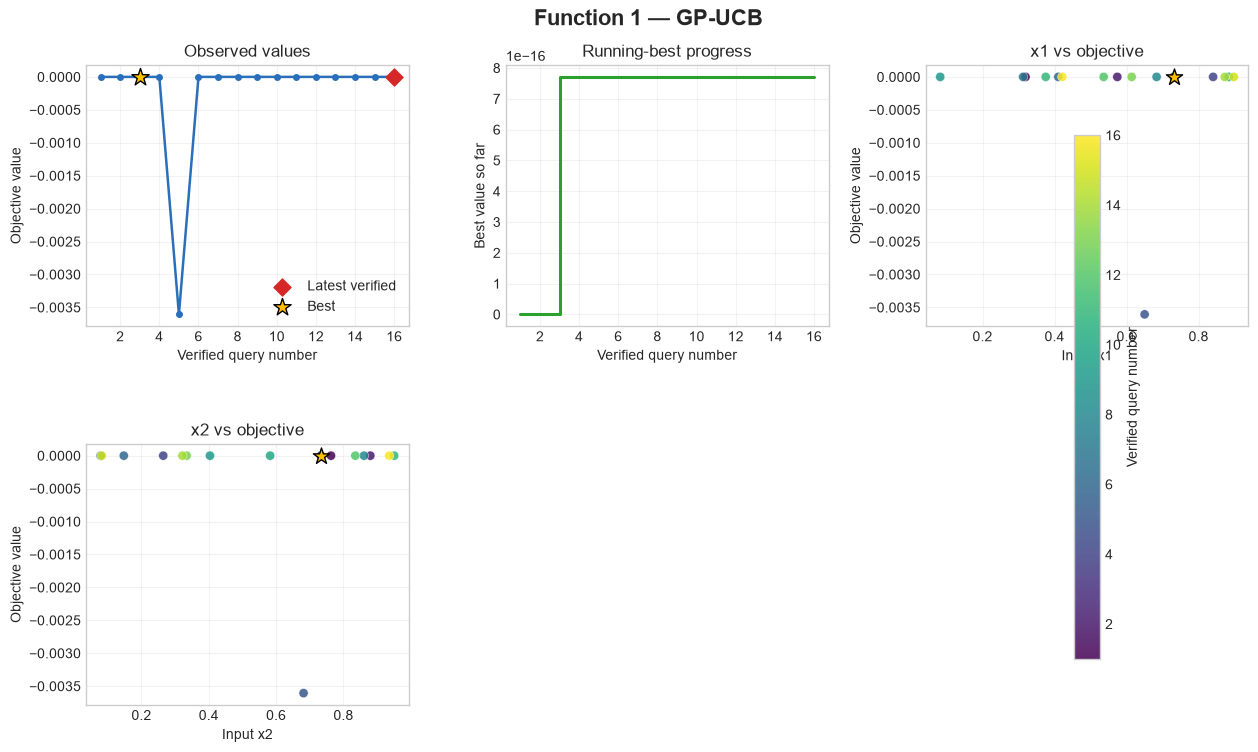

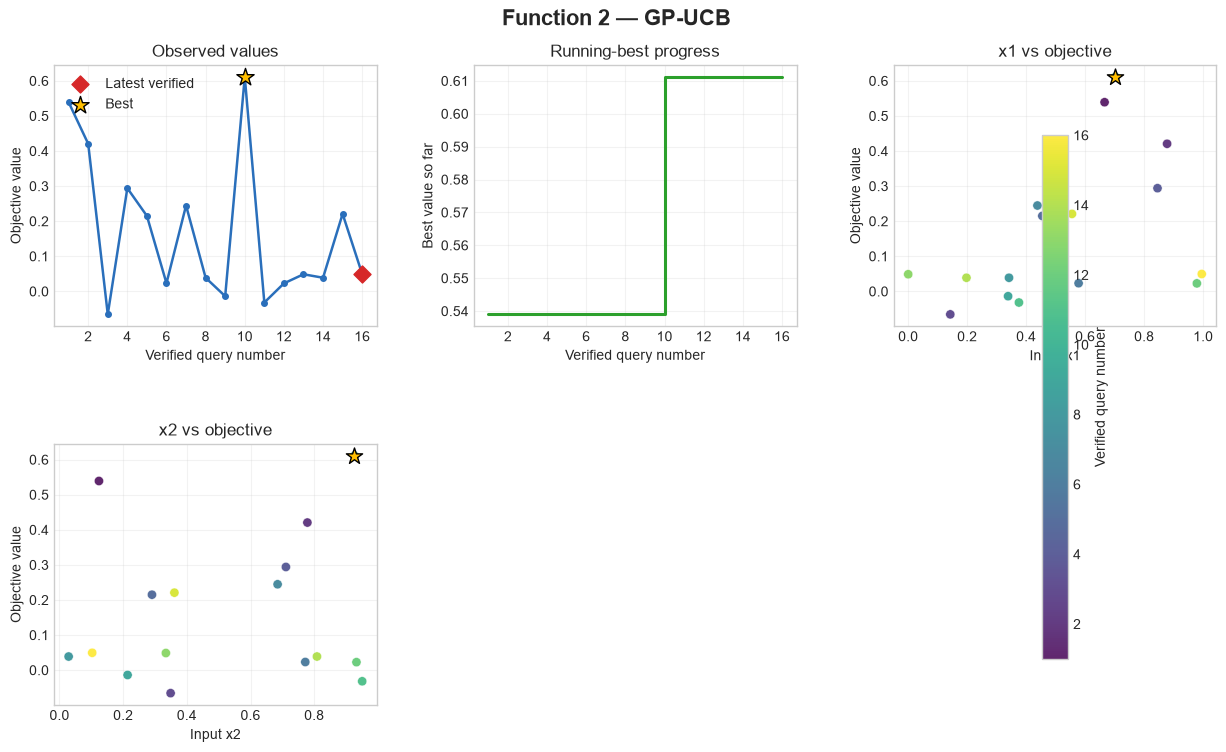

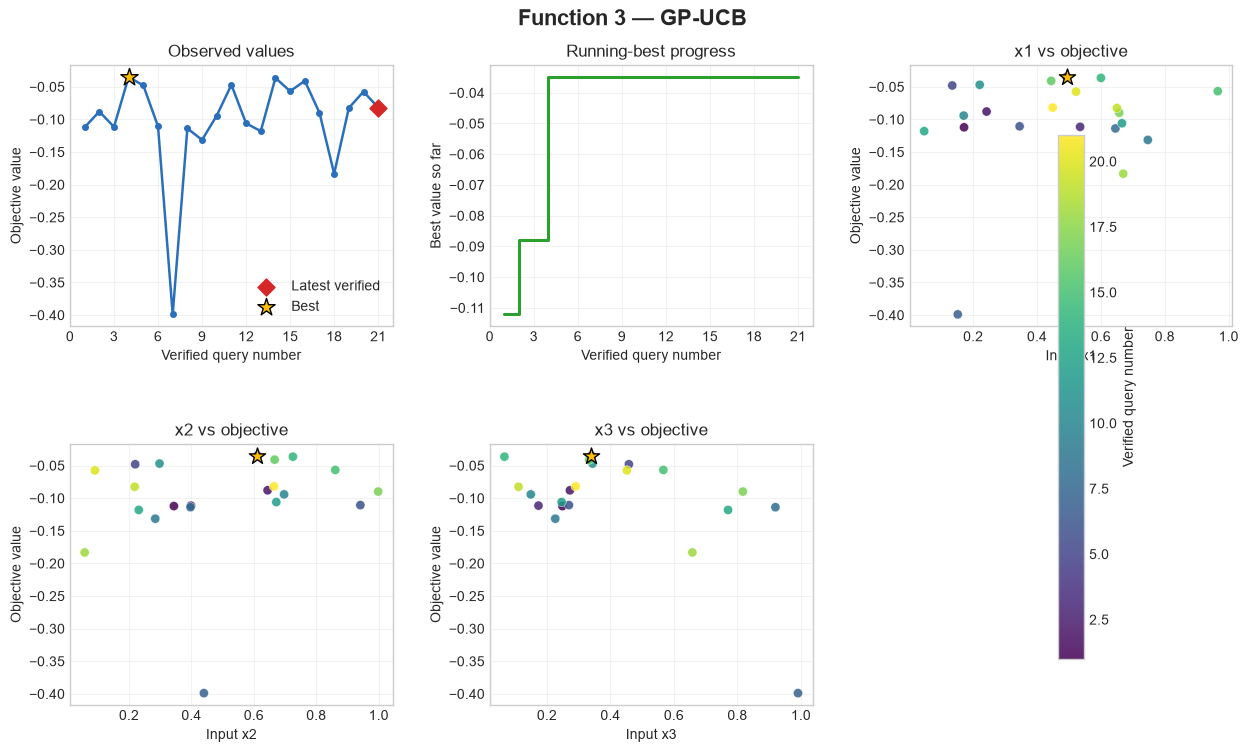

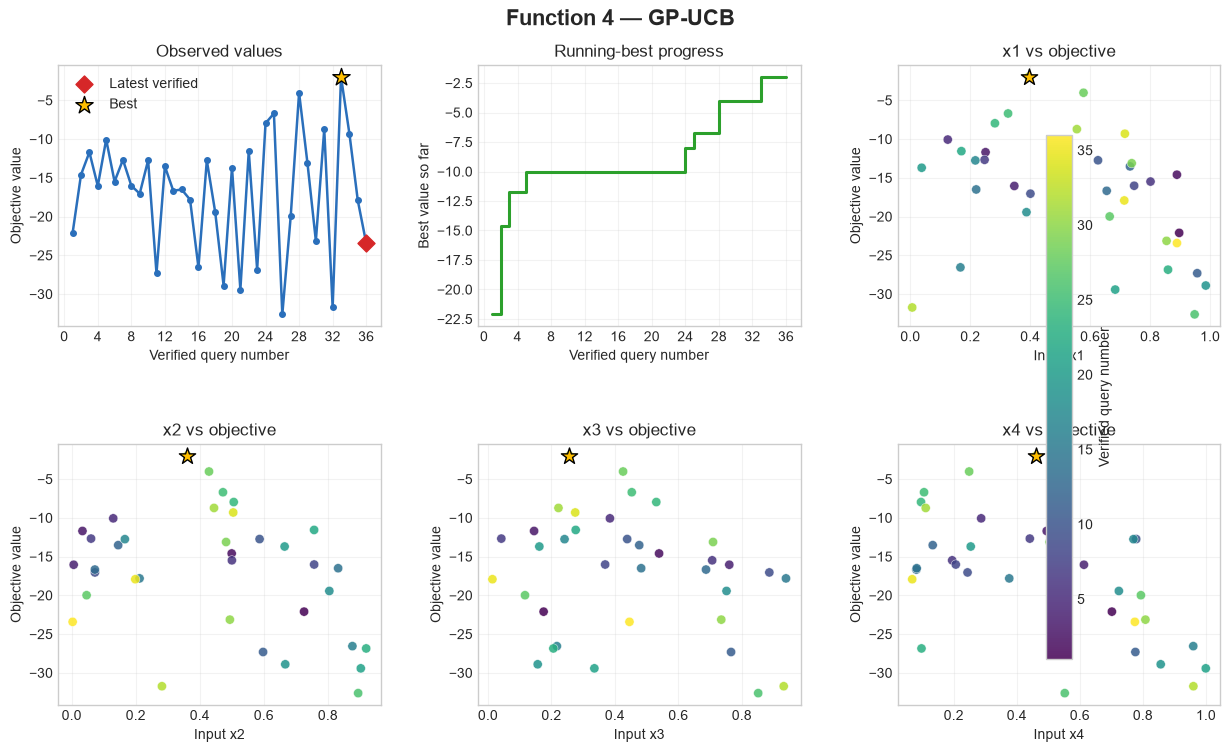

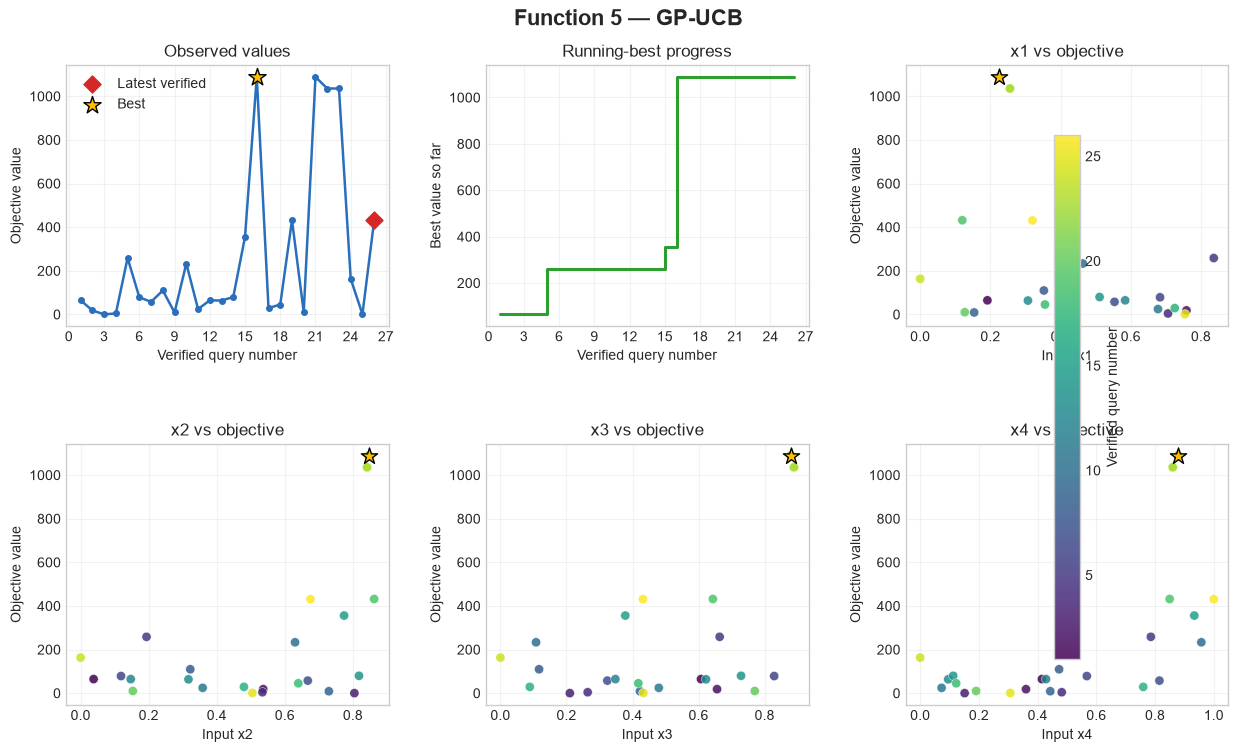

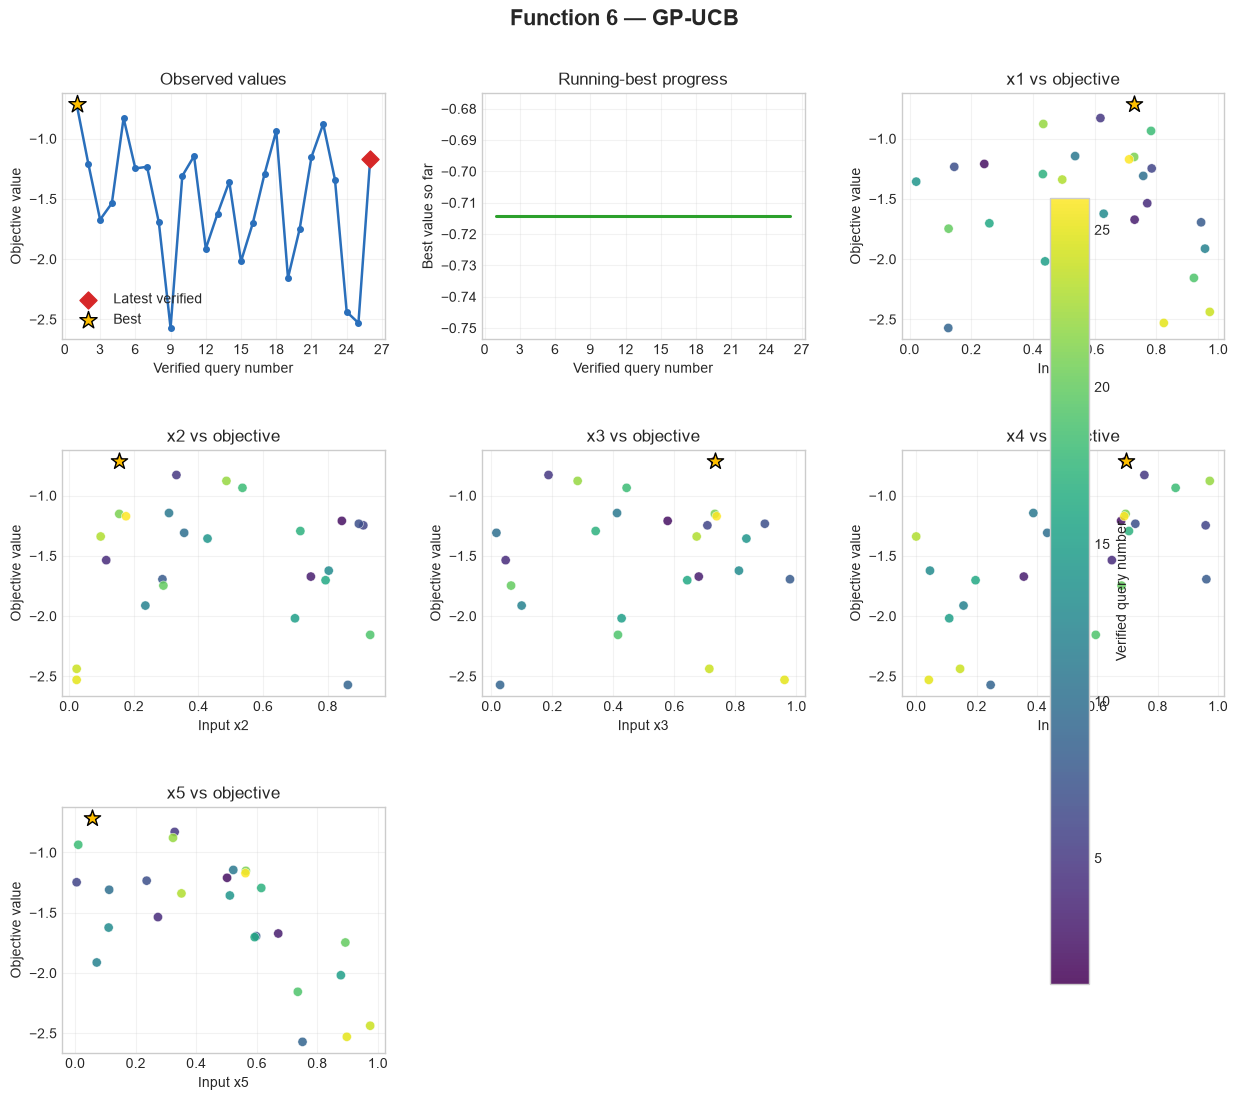

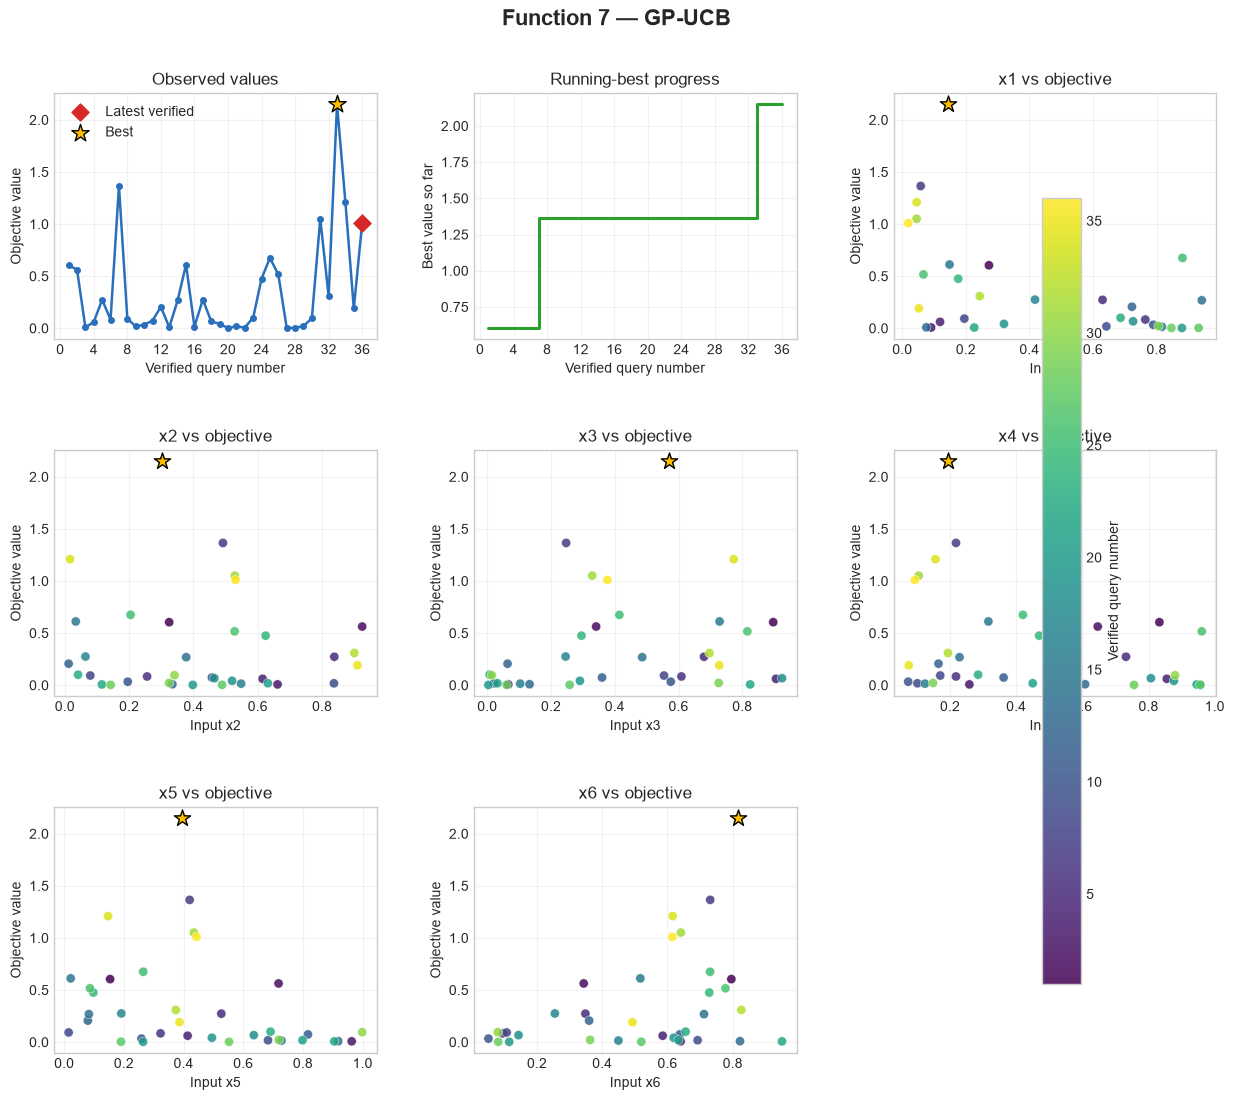

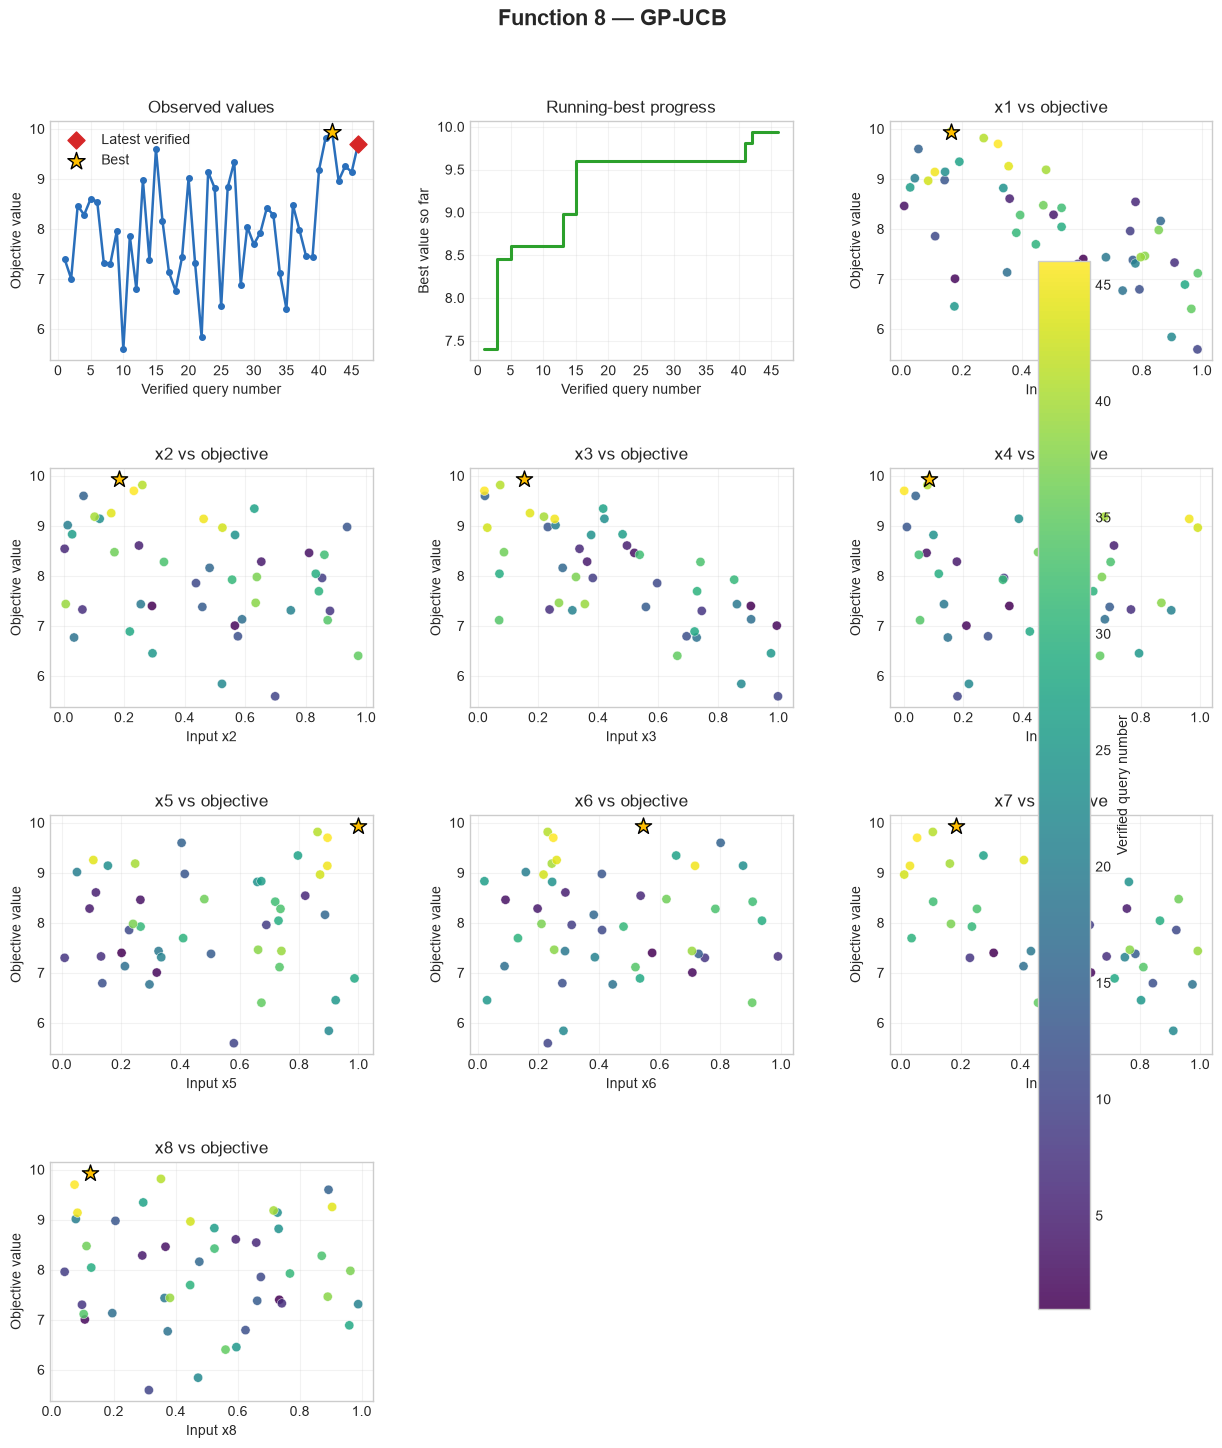

Rendered 8 function diagnostic figures.


In [7]:
def plot_function(fn):
    X,y=load_verified(fn); q=np.arange(1,len(y)+1); best=int(np.argmax(y)); panels=X.shape[1]+2; rows=math.ceil(panels/3); fig,axes=plt.subplots(rows,3,figsize=(15,4*rows),squeeze=False); axes=axes.ravel()
    axes[0].plot(q,y,color='#2a6fbb',marker='o',lw=1.8,ms=4); axes[0].scatter(q[-1],y[-1],marker='D',color='#d62728',s=75,zorder=4,label='Latest verified'); axes[0].scatter(q[best],y[best],marker='*',color='#ffbf00',edgecolor='black',s=170,zorder=5,label='Best'); axes[0].set(xlabel='Verified query number',ylabel='Objective value',title='Observed values'); axes[0].legend(); axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].step(q,np.maximum.accumulate(y),where='post',color='#2ca02c',lw=2.2); axes[1].set(xlabel='Verified query number',ylabel='Best value so far',title='Running-best progress'); axes[1].xaxis.set_major_locator(MaxNLocator(integer=True)); colour=None
    for col,axis in enumerate(axes[2:2+X.shape[1]]): colour=axis.scatter(X[:,col],y,c=q,cmap='viridis',s=44,alpha=.85,edgecolor='white',lw=.35); axis.scatter(X[best,col],y[best],marker='*',color='#ffbf00',edgecolor='black',s=150,zorder=5); axis.set(xlabel=f'Input x{col+1}',ylabel='Objective value',title=f'x{col+1} vs objective')
    for axis in axes[panels:]: axis.set_visible(False)
    for axis in axes[:panels]: axis.grid(True,alpha=.25)
    fig.colorbar(colour,ax=axes[2:2+X.shape[1]].tolist(),label='Verified query number',shrink=.85); fig.suptitle(f'Function {fn} — GP-UCB',fontsize=16,fontweight='bold'); fig.subplots_adjust(top=.91,hspace=.45,wspace=.30); return fig
figures=[plot_function(i) for i in FUNCTIONS]; plt.show(); print(f'Rendered {len(figures)} function diagnostic figures.')

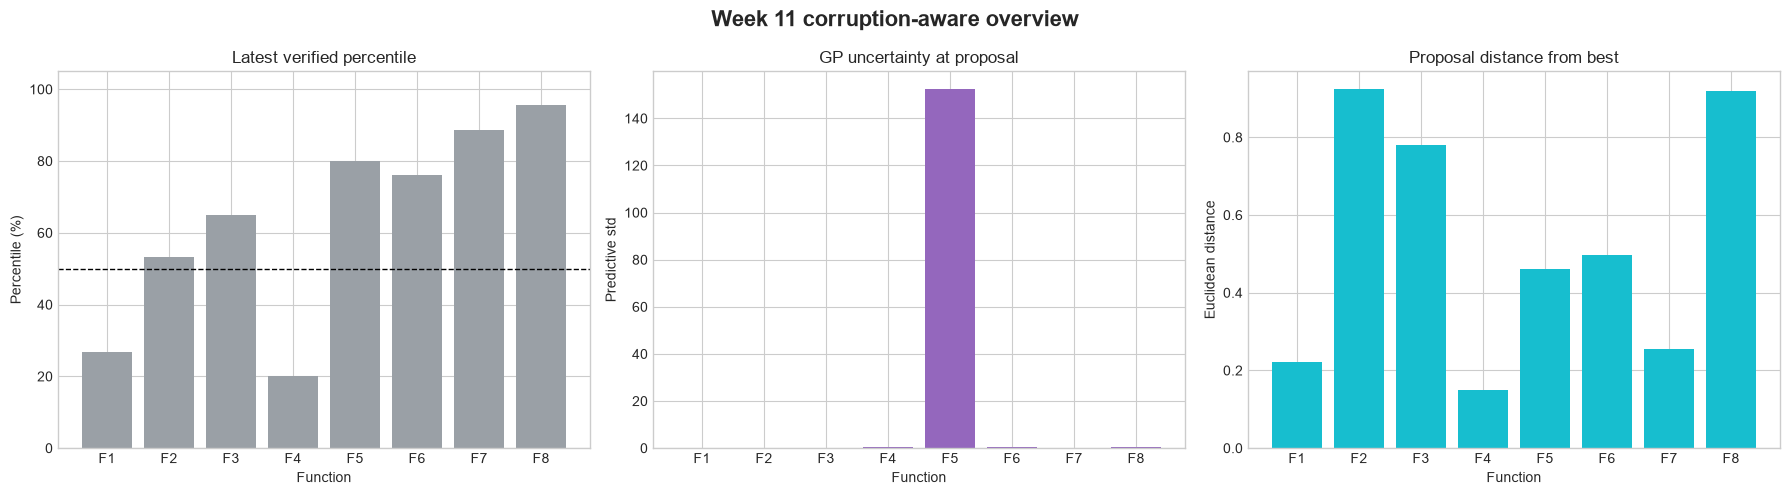

In [8]:
fig,axes=plt.subplots(1,3,figsize=(18,5)); colours=np.where(performance['Latest improvement']>0,'#2ca02c','#9aa0a6')
axes[0].bar(performance['Function'],performance['Latest percentile'],color=colours); axes[0].axhline(50,color='black',ls='--',lw=1); axes[0].set(title='Latest verified percentile',xlabel='Function',ylabel='Percentile (%)',ylim=(0,105))
axes[1].bar(proposal_summary['Function'],proposal_summary['Predictive std'],color='#9467bd'); axes[1].set(title='GP uncertainty at proposal',xlabel='Function',ylabel='Predictive std')
axes[2].bar(proposal_summary['Function'],proposal_summary['Distance from best'],color='#17becf'); axes[2].set(title='Proposal distance from best',xlabel='Function',ylabel='Euclidean distance')
fig.suptitle('Week 11 corruption-aware overview',fontsize=16,fontweight='bold'); fig.tight_layout(); plt.show()

## Reproducible checks

In [9]:
expected={1:16,2:16,3:21,4:36,5:26,6:26,7:36,8:46}
for fn in FUNCTIONS:
    X,y=load_verified(fn); s=summarize(fn); q=week11_queries[fn]
    assert X.shape==(expected[fn],DIMS[fn]) and y.shape==(expected[fn],) and np.allclose(X[-1],W9Q[fn]) and np.isclose(y[-1],W9Y[fn])
    assert s['Best query']==int(np.argmax(y))+1 and q.shape==(DIMS[fn],) and np.all((q>=0)&(q<=1)) and not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1))
assert sum(expected.values())==223 and len(performance)==len(proposal_summary)==len(week11_queries)==8
assert performance['Evidence gaps'].eq('Weeks 5, 7, and 10 pending').all()
print('All Week 11 verified-data, performance, GP-UCB proposal, and plotting checks passed.')

All Week 11 verified-data, performance, GP-UCB proposal, and plotting checks passed.
